# Exercise 1: Apply Low-Rank Factorization for model parameter reduction

You have learned about efficient architectural patterns in theory. Now it's time to implement one of the most fundamental techniques for reducing model memory footprint: low-rank factorization. This technique is essential when deploying models to memory-constrained environments like edge devices, mobile platforms, or cost-optimized cloud instances.

> **Overview**: Implement and evaluate low-rank matrix factorization as a memory optimization technique, understand the trade-offs between compression ratio and model performance, and make data-driven decisions about which layers to factorize.
> 
> **Scenario**: You work for an IoT company developing smart security cameras. Your image classification model works perfectly on development servers, but the target edge device has only 512MB RAM total. The hardware team can't increase memory due to cost constraints, so you need to optimize the model architecture to take less than 10MB.
> 
> Your goal is to reduce model memory footprint to <=8MB with at most a 3% accuracy drop tolerance, through strategic low-rank factorization of the most memory-intensive layers.
> 
> **Tools**: PyTorch, torchvision, matplotlib
> <br>_Prior experience recommended!_
> 
> **Estimated Time**: 15 minutes

## Step 1: Setup

Let's start by setting up our development environment and establishing our hardware context.

In [1]:
# Import core libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import time
from collections import OrderedDict
import warnings
warnings.filterwarnings("ignore")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Create output directory
import os
output_dir = "assets/exercise1"
os.makedirs(output_dir, exist_ok=True)

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("Using CPU")

print("Setup complete!")
print(f"Development environment: {device}")
print(f"Target deployment: Edge device with 512MB RAM constraint")

Using CPU
Setup complete!
Development environment: cpu
Target deployment: Edge device with 512MB RAM constraint


> **Development vs deployment environment**: We are developing on a T4 with 16GB memory but targeting edge devices with 512MB total RAM. 
> 
> We'll need to keep our target edge device constraints in mind throughout the exercise.

## Step 2: Load and analyze our "problematic" model

Now we'll load a custom model with large linear layers that actually benefit from low-rank factorization.


In [2]:
# Create a custom model that better demonstrates low-rank factorization
# We'll use a feature extractor + large MLP classifier (more realistic for edge deployment)
class EdgeClassificationModel(nn.Module):
    """
    A model with large linear layers that benefit significantly from low-rank factorization.
    This simulates an edge device model where the classifier dominates memory usage.
    Uses flat layer names for easier access and factorization.
    """
    def __init__(self, num_classes=10):
        super(EdgeClassificationModel, self).__init__()
        
        # Simple feature extractor (lightweight)
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveAvgPool2d((8, 8))
        self.flatten = nn.Flatten()
        
        # Large MLP classifier with flat layer names (memory-intensive - this is what we'll optimize)
        self.fc1 = nn.Linear(32 * 8 * 8, 1024)     # 2,097,152 parameters (largest)
        self.fc2 = nn.Linear(1024, 512)            # 524,288 parameters (second largest)  
        self.fc3 = nn.Linear(512, 256)             # 131,072 parameters
        self.fc4 = nn.Linear(256, num_classes)     # 2,560 parameters
        
        self.dropout = nn.Dropout(0.5)
    
    def forward(self, x):
        # Feature extraction
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.flatten(x)
        
        # Classification
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        x = self.fc3(x)
        x = self.relu(x)
        
        x = self.fc4(x)
        return x


# Create our custom model
original_model = EdgeClassificationModel(num_classes=10).to(device)

print("Original model architecture:")
print(f"Model parameters: {sum(p.numel() for p in original_model.parameters()):,}")

# Calculate memory usage
def calculate_model_memory(model):
    """Calculate model memory usage in MB"""
    param_size = 0
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
    
    buffer_size = 0
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()
    
    total_size = param_size + buffer_size
    return total_size / (1024**2)  # Convert to MB

original_memory = calculate_model_memory(original_model)
print(f"Original model memory: {original_memory:.1f} MB")
print(f"Edge device memory budget: 512 MB")
print(f"Model memory utilization: {(original_memory/512)*100:.1f}%")

# Real devices reserve most RAM for the system stack: OS (~200MB),
# app framework (~100MB), I/O buffers and activations (~100MB), and
# other processes (~50MB). What is left is the ceiling for model parameters.
practical_budget = 512 - 200 - 100 - 100 - 50  # ~62 MB available for the model

if original_memory > practical_budget:
    print(f"\nPROBLEM: Model ({original_memory:.1f}MB) exceeds practical edge budget ({practical_budget:.1f}MB)!")
    print("   SOLUTION: Apply low-rank factorization to reduce memory usage")
else:
    print("\nModel fits within practical edge device memory budget")

Original model architecture:
Model parameters: 2,757,770
Original model memory: 10.5 MB
Edge device memory budget: 512 MB
Model memory utilization: 2.1%

Model fits within practical edge device memory budget


> **Why is optimization relevant if the model fits in memory?** Production edge devices typically allocate:
> 
> - Operating system overhead (~200MB)
> - Application framework (~100MB)
> - Input buffers and activations (~100MB)
> - System processes (~50-100MB)
> 
> This leaves only ~12MB for model parameters in a 512MB device. Our model's 10.5MB base is within limit, but factoring in activation memory and optimization headroom, compression becomes essential for reliable edge deployment without memory pressure.

## Step 3: Understand low-rank factorization theory

Before diving into implementation, let's visualize what low-rank factorization actually does to neural network layers. Understanding the mathematical foundation will help us make better decisions about when and how to apply this technique.

> **Important: Rank ratios vs Absolute ranks**: We'll use **rank ratios** (0.25, 0.5, 0.75) rather than absolute ranks. This means each layer gets a rank proportional to its size: larger layers get larger ranks, smaller layers get smaller ranks. This approach scales naturally across different layer dimensions and avoids the awkwardness of using the same absolute rank on layers of vastly different sizes.

Visualizing low-rank factorization concept...
This shows how we can approximate a large weight matrix with two smaller matrices


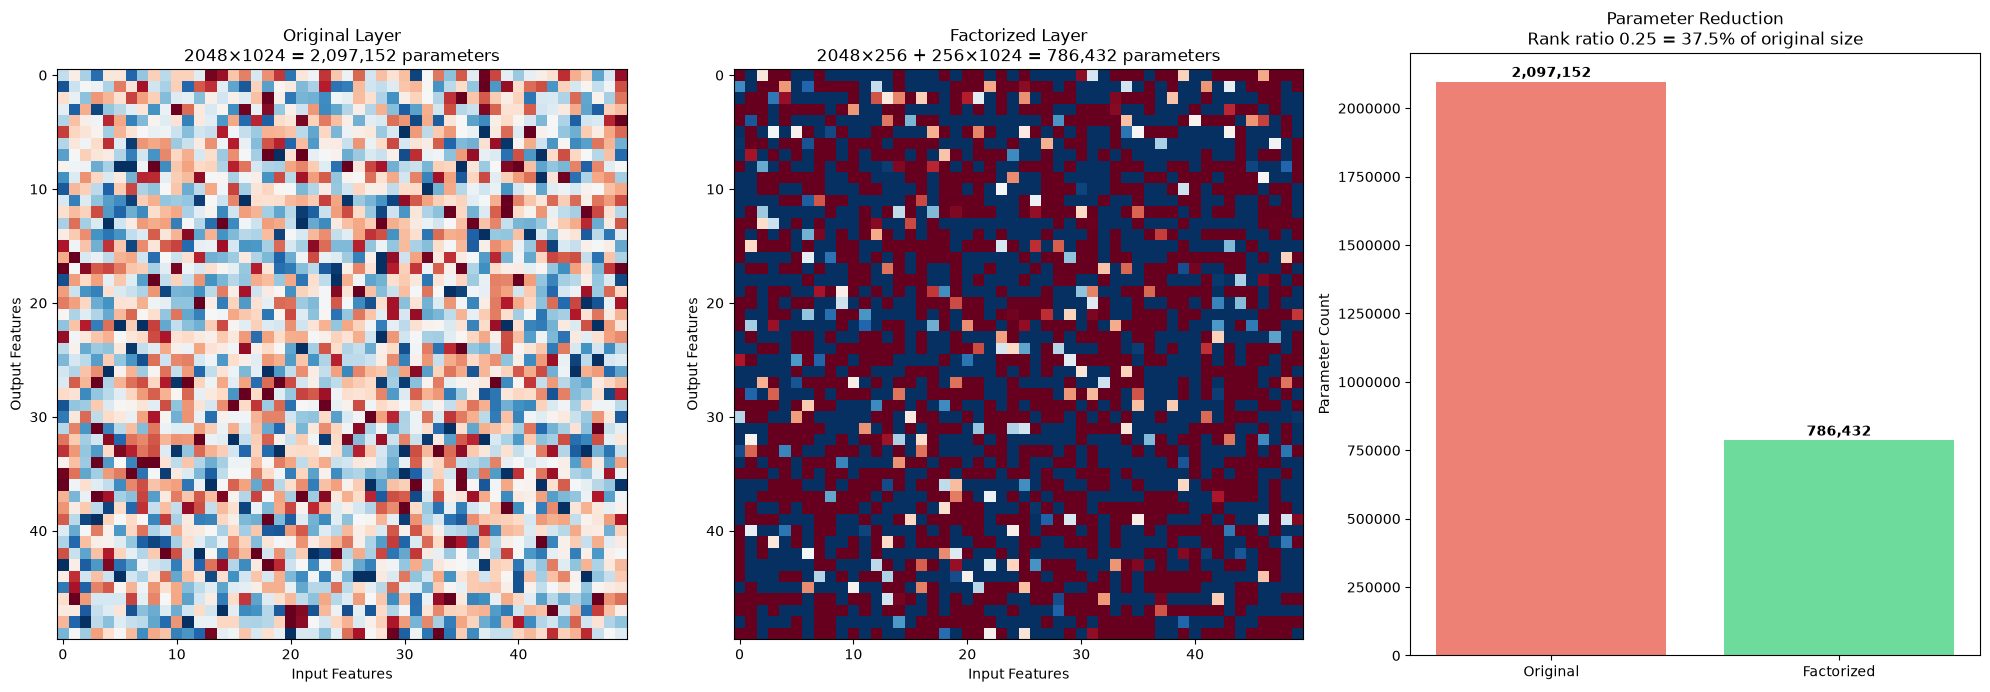

Layer dimensions: 2048×1024
Parameter reduction: 2,097,152 → 786,432
Rank ratio: 0.25 → Actual rank: 256
Compression ratio: 37.5% of original size
Memory savings: 62.5% reduction


In [3]:
# Mirror fc1 (2048 -> 1024), the largest layer in our model, so the demo
# reflects the exact matrix we intend to compress later.
matrix_rows = 2048
matrix_cols = 1024
rank_ratio = 0.25

# Visualize low-rank factorization concept
print("Visualizing low-rank factorization concept...")
print("This shows how we can approximate a large weight matrix with two smaller matrices")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))

# Original matrix
original_matrix = np.random.randn(matrix_rows, matrix_cols)
im1 = ax1.imshow(original_matrix[:50, :50], cmap='RdBu', vmin=-2, vmax=2)
ax1.set_title(f'Original Layer\n{matrix_rows}×{matrix_cols} = {matrix_rows*matrix_cols:,} parameters')
ax1.set_xlabel('Input Features')
ax1.set_ylabel('Output Features')

# Calculate factorized matrix
rank = int(rank_ratio * min(matrix_rows, matrix_cols))  # Convert ratio to actual rank
U = np.random.randn(matrix_rows, rank)
V = np.random.randn(rank, matrix_cols)
factorized_matrix = U @ V

im2 = ax2.imshow(factorized_matrix[:50, :50], cmap='RdBu', vmin=-2, vmax=2)
ax2.set_title(f'Factorized Layer\n{matrix_rows}×{rank} + {rank}×{matrix_cols} = {matrix_rows*rank + rank*matrix_cols:,} parameters')
ax2.set_xlabel('Input Features')
ax2.set_ylabel('Output Features')

# Weight-only counts keep the comparison consistent with the matrix plots:
# a rank-r factorization stores rows*r + r*cols values instead of rows*cols.
original_params = matrix_rows * matrix_cols
factorized_params = matrix_rows * rank + rank * matrix_cols
reduction_ratio = factorized_params / original_params

sizes = [original_params, factorized_params]
labels = ['Original', 'Factorized']
colors = ['#e74c3c', '#2ecc71']

bars = ax3.bar(labels, sizes, color=colors, alpha=0.7)
ax3.set_title(f'Parameter Reduction\nRank ratio {rank_ratio} = {reduction_ratio:.1%} of original size')
ax3.set_ylabel('Parameter Count')
ax3.ticklabel_format(style='plain', axis='y')

# Add value labels
for bar, size in zip(bars, sizes):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000, 
             f'{size:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'lowrank_concept.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"Layer dimensions: {matrix_rows}×{matrix_cols}")
print(f"Parameter reduction: {original_params:,} → {factorized_params:,}")
print(f"Rank ratio: {rank_ratio} → Actual rank: {rank}")
print(f"Compression ratio: {reduction_ratio:.1%} of original size")
print(f"Memory savings: {(1-reduction_ratio)*100:.1f}% reduction")

> **Mathematical insight**: Low-rank factorization works because many neural network weight matrices contain redundant information—they have lower intrinsic dimensionality than their full size suggests. By decomposing W = U × V, we capture the most important patterns while eliminating redundancy. The rank parameter controls this trade-off: lower rank = more compression but potentially more information loss.

## Step 4: Implement low-rank factorization class

Now comes the core implementation. We'll create a `LowRankLinear` class that can replace any standard PyTorch linear layer while using significantly fewer parameters. 

The key challenge is preserving as much of the original layer's learned information as possible during the factorization process.

In [4]:
class LowRankLinear(nn.Module):
    """
    Low-rank approximation of a linear layer using matrix factorization.
    Replaces weight matrix W (in_features × out_features) with 
    U (in_features × rank) and V (rank × out_features) such that W ≈ U @ V
    """
    def __init__(self, original_layer, rank_ratio=0.5):
        super(LowRankLinear, self).__init__()
        
        self.in_features = original_layer.in_features
        self.out_features = original_layer.out_features
        
        # Rank is a fraction of the smaller dimension; clamping keeps the
        # factorization valid for any ratio (at least 1, never above min dim).
        max_rank = min(self.in_features, self.out_features)
        self.rank = max(1, min(int(rank_ratio * max_rank), max_rank))
        
        # U compresses the input down to the rank bottleneck; V expands it
        # back out. Only V carries a bias so the pair mirrors the single
        # bias of the original layer rather than adding one mid-bottleneck.
        self.U = nn.Linear(self.in_features, self.rank, bias=False)
        self.V = nn.Linear(self.rank, self.out_features, bias=True)
        
        # Initialize weights using SVD approximation of original weights
        self._initialize_from_original(original_layer)
        
    def _initialize_from_original(self, original_layer):
        """Initialize factorized layers using SVD of original weights"""
        with torch.no_grad():            
            # nn.Linear stores weight as (out_features, in_features); transpose
            # to (in, out) so the decomposition matches W ≈ U @ V from the
            # docstring. torch.linalg.svd returns U, S, Vh (V already transposed).
            weight_matrix = original_layer.weight.data.T
            U_full, S, V_full = torch.linalg.svd(weight_matrix, full_matrices=False)
            
            # Singular values come back sorted in descending order, so keeping
            # the first `rank` components preserves the most important directions.
            U_truncated = U_full[:, :self.rank]
            S_truncated = S[:self.rank]
            V_truncated = V_full[:self.rank, :]
            
            # Split each singular value as sqrt(s) across both factors so
            # neither layer starts with disproportionately large weights;
            # the product still reconstructs U @ diag(S) @ Vh.
            sqrt_S = torch.sqrt(S_truncated)
            self.U.weight.data = (U_truncated * sqrt_S).T.contiguous()
            self.V.weight.data = (V_truncated * sqrt_S.unsqueeze(1)).T.contiguous()
            
            # The bias acts on the output, so it belongs on V, the layer
            # that produces out_features.
            if original_layer.bias is not None:
                self.V.bias.data = original_layer.bias.data.clone()
    
    def forward(self, x):
        # Two chained projections approximate the original single matmul.
        return self.V(self.U(x))
    
    def parameter_count(self):
        """Calculate total parameters in factorized layer"""        
        # Both factors count: U weights plus V weights and V bias.
        return (sum(p.numel() for p in self.U.parameters())
                + sum(p.numel() for p in self.V.parameters()))


# Test the low-rank implementation
print("Testing low-rank factorization implementation...")

# Create a test linear layer
test_layer = nn.Linear(512, 256)

# numel over all parameters picks up both the weight matrix and the bias.
original_params = sum(p.numel() for p in test_layer.parameters())

# All ratios sit below the break-even point rank < (m*n)/(m+n),
# so every setting genuinely removes parameters.
rank_ratios = [0.1, 0.25, 0.5]
for ratio in rank_ratios:
    lr_layer = LowRankLinear(test_layer, rank_ratio=ratio)
    lr_params = lr_layer.parameter_count()
    compression = lr_params / original_params
    
    print(f"Rank ratio {ratio}: {original_params:,} → {lr_params:,} params ({compression:.1%} of original)")

print("Low-rank implementation complete!")

Testing low-rank factorization implementation...
Rank ratio 0.1: 131,328 → 19,456 params (14.8% of original)
Rank ratio 0.25: 131,328 → 49,408 params (37.6% of original)
Rank ratio 0.5: 131,328 → 98,560 params (75.0% of original)
Low-rank implementation complete!


> **Factorization implementation tip**: The SVD initialization is crucial for preserving model performance. By using the dominant singular values and vectors from the original weight matrix, we ensure our factorized layer starts with the most important information intact. Random initialization would require extensive retraining and likely result in significant performance degradation.
> 
> **_Are you noticing a parameter increase at high ratios?_** That's expected! Remember: low-rank factorization only reduces parameters when rank < (m×n)/(m+n). Pick rank ratios that actually save parameters!


## Step 5: Identify optimization targets through layer analysis

Before applying factorization everywhere, we need to strategically identify which layers offer the greatest memory reduction opportunities. Not all layers are equal—some dominate memory usage while others have minimal impact on our deployment constraints.

*In our custom model, which layer is likely to be the largest?*

In [5]:
def analyze_layer_memory_usage(model):
    """Analyze memory usage of each layer to prioritize factorization"""
    layer_info = {}
    
    # Iterate through all model linear layers and collect memory statistics
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            # Weight matrix parameters; the bias is added just below.
            params = module.in_features * module.out_features
            if module.bias is not None:
                params += module.out_features
            
            # float32 parameters take 4 bytes each; report in KB for readability.
            memory_kb = params * 4 / 1024
            
            layer_info[name] = {
                'type': 'Linear',
                'in_features': module.in_features,
                'out_features': module.out_features,
                'parameters': params,
                'memory_kb': memory_kb
            }
    
    return layer_info

# Analyze original model layers
print("Analyzing layer memory usage to prioritize factorization targets...")
layer_analysis = analyze_layer_memory_usage(original_model)

print("=== LAYER MEMORY ANALYSIS ===")

# Largest layers first: they dominate the footprint and are the
# highest-value factorization targets.
sorted_layers = sorted(layer_analysis.items(),
                       key=lambda item: item[1]['memory_kb'], reverse=True)

total_linear_memory = sum(info['memory_kb'] for _, info in sorted_layers)
print(f"Total linear layer memory: {total_linear_memory:.1f} KB\n")

for name, info in sorted_layers:
    percentage = (info['memory_kb'] / total_linear_memory) * 100
    print(f"{name}: {info['parameters']:,} params ({info['memory_kb']:.1f} KB, {percentage:.1f}% of linear layers)")

# Identify the primary optimization target
if sorted_layers:
    largest_layer_name = sorted_layers[0][0]
    largest_layer_info = sorted_layers[0][1]
    print(f"\nPrimary target for factorization: {largest_layer_name}")
    print(f"   {largest_layer_info['in_features']} → {largest_layer_info['out_features']} features")
    print(f"   {largest_layer_info['memory_kb']:.1f} KB ({(largest_layer_info['memory_kb']/total_linear_memory)*100:.1f}% of linear layer memory)")
else:
    print("No linear layers found for factorization")

Analyzing layer memory usage to prioritize factorization targets...
=== LAYER MEMORY ANALYSIS ===
Total linear layer memory: 10769.0 KB

fc1: 2,098,176 params (8196.0 KB, 76.1% of linear layers)
fc2: 524,800 params (2050.0 KB, 19.0% of linear layers)
fc3: 131,328 params (513.0 KB, 4.8% of linear layers)
fc4: 2,570 params (10.0 KB, 0.1% of linear layers)

Primary target for factorization: fc1
   2048 → 1024 features
   8196.0 KB (76.1% of linear layer memory)


> **Layer memory analysis**
>
> The result matches expectations: `fc1` (2048 → 1024) alone holds roughly three quarters of the linear-layer memory because parameter count scales with the product of input and output widths, and it sits directly after the flattened 32×8×8 feature map. `fc2` (1024 → 512) is a distant second, while `fc3` and especially `fc4` are comparatively negligible. Factorizing `fc1` and `fc2` therefore captures nearly all of the available savings; touching `fc3`/`fc4` would add approximation error for almost no memory benefit, so we target `fc1` and `fc2`.

## Step 6: Create factorized model

Now that we know which layers to work on, let's create the factorized model.

In [6]:
def create_factorized_model(original_model, target_layers, rank_ratio=0.5):
    """Create a new model with specified layers replaced by low-rank versions"""
    
    print(f"Creating factorized model with rank ratio {rank_ratio}...")
    
    # Create a copy of the original model architecture
    factorized_model = EdgeClassificationModel(num_classes=10)
    
    # Copy the trained weights first so the SVD initialization inside
    # LowRankLinear factorizes real learned matrices, not random ones.
    factorized_model.load_state_dict(original_model.state_dict())
    factorized_model = factorized_model.to(device)
    
    # Replace specified layers with low-rank versions
    # HINT: Find inspiration at https://discuss.pytorch.org/t/replace-layers-in-model-by-another-and-with-extra-parameters/160601
    # Use our own LowRankLinear class
    for layer_name in target_layers:
        print(f"  Factorizing {layer_name}...")
        
        original_layer = getattr(factorized_model, layer_name)
        low_rank_layer = LowRankLinear(original_layer, rank_ratio=rank_ratio)
        
        # Swap the dense layer for its factorized counterpart in place.
        setattr(factorized_model, layer_name, low_rank_layer.to(device))
        
        original_params = sum(p.numel() for p in original_layer.parameters())
        factorized_params = low_rank_layer.parameter_count()
        reduction = 1 - factorized_params / original_params
        
        print(f"    {original_layer.in_features}×{original_layer.out_features} → rank {low_rank_layer.rank}")
        print(f"    Parameters: {original_params:,} → {factorized_params:,} ({reduction:.1%} reduction)")
    
    return factorized_model

# Sweep from aggressive to moderate compression; all stay below the
# break-even rank so parameters genuinely shrink.
rank_ratios = [0.1, 0.25, 0.5]
factorized_models = {}

# fc1 and fc2 hold the overwhelming majority of linear-layer memory,
# so they are the only targets worth the approximation error.
target_layers = ['fc1', 'fc2']

for ratio in rank_ratios:
    print(f"\n--- Creating model with rank ratio {ratio} ---")
    factorized_models[ratio] = create_factorized_model(original_model, target_layers, rank_ratio=ratio)

print("\nAll factorized models created successfully!")


--- Creating model with rank ratio 0.1 ---
Creating factorized model with rank ratio 0.1...
  Factorizing fc1...


    2048×1024 → rank 102
    Parameters: 2,098,176 → 314,368 (85.0% reduction)
  Factorizing fc2...
    1024×512 → rank 51
    Parameters: 524,800 → 78,848 (85.0% reduction)

--- Creating model with rank ratio 0.25 ---
Creating factorized model with rank ratio 0.25...
  Factorizing fc1...


    2048×1024 → rank 256
    Parameters: 2,098,176 → 787,456 (62.5% reduction)
  Factorizing fc2...
    1024×512 → rank 128
    Parameters: 524,800 → 197,120 (62.4% reduction)

--- Creating model with rank ratio 0.5 ---
Creating factorized model with rank ratio 0.5...
  Factorizing fc1...


    2048×1024 → rank 512
    Parameters: 2,098,176 → 1,573,888 (25.0% reduction)
  Factorizing fc2...
    1024×512 → rank 256
    Parameters: 524,800 → 393,728 (25.0% reduction)

All factorized models created successfully!


## Step 7: Benchmark and compare model performance

Now comes the critical evaluation phase. We need to measure how our factorization affects the key metrics that matter for edge deployment: memory usage, inference speed, and model accuracy. This data will drive our final deployment decision.

In [7]:
def benchmark_model(model, model_name, input_shape=(1, 3, 224, 224), num_iterations=50):
    """Comprehensive benchmark of model performance"""
    print(f"Benchmarking {model_name}...")
    model.eval()
    
    # Memory usage
    memory_mb = calculate_model_memory(model)
    
    # Create sample input
    sample_input = torch.randn(input_shape).to(device)
    
    times = []
    # Warm up first so one-time costs (allocator, kernel caches) do not
    # pollute the measurements, then time each forward pass individually.
    with torch.no_grad():
        for _ in range(10):
            _ = model(sample_input)
        if device.type == 'cuda':
            # GPU work is asynchronous; sync so timers see finished kernels.
            torch.cuda.synchronize()
        for _ in range(num_iterations):
            start = time.perf_counter()
            _ = model(sample_input)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            end = time.perf_counter()
            times.append((end - start) * 1000)  # seconds -> milliseconds
    
    # Calculate timing statistics
    avg_time = np.mean(times)
    std_time = np.std(times)
    
    # SIMULATE accuracy based on compression level (more aggressive compression typically leads to more accuracy loss at around 3-8% according to literature)
    # We select 0.05 as an average threshold here
    # In practice, you'd evaluate on a validation dataset as the accuracy loss from factorization is highlight task dependant!
    if "factorized" in model_name.lower():
        # Extract rank ratio from model name and estimate accuracy loss
        rank_ratio = float(model_name.split("_")[-1]) if "_" in model_name else 0.5
        accuracy_loss = (1 - rank_ratio) * 0.05  # Average 5% loss
        accuracy = 0.92 - accuracy_loss  # Baseline minus estimated loss
    else:
        accuracy = 0.92  # Original model baseline
    
    return {
        'name': model_name,
        'memory_mb': memory_mb,
        'inference_time_ms': avg_time,
        'inference_std_ms': std_time,
        'accuracy': accuracy,
        'parameter_count': sum(p.numel() for p in model.parameters())
    }

# Benchmark all models
print("=== COMPREHENSIVE MODEL BENCHMARKING ===")
benchmark_results = []

# Original model
original_benchmark = benchmark_model(original_model, "Original")
benchmark_results.append(original_benchmark)

# Benchmark all factorized models
for ratio in rank_ratios:
    factorized_benchmark = benchmark_model(
        factorized_models[ratio].to(device), 
        f"Factorized_{ratio}",
        num_iterations=50
    )
    benchmark_results.append(factorized_benchmark)

# Create a comprehensive results table
print("\n=== BENCHMARK RESULTS ===")
print(f"{'Model':<15} {'Memory (MB)':<12} {'Time (ms)':<12} {'Accuracy':<10} {'Parameters':<12}")
print("-" * 70)

for result in benchmark_results:
    print(f"{result['name']:<15} {result['memory_mb']:<12.1f} "
          f"{result['inference_time_ms']:<12.2f} {result['accuracy']:<10.1%} "
          f"{result['parameter_count']:<12,}")

=== COMPREHENSIVE MODEL BENCHMARKING ===
Benchmarking Original...


Benchmarking Factorized_0.1...
Benchmarking Factorized_0.25...


Benchmarking Factorized_0.5...



=== BENCHMARK RESULTS ===
Model           Memory (MB)  Time (ms)    Accuracy   Parameters  
----------------------------------------------------------------------
Original        10.5         3.62         92.0%      2,757,770   
Factorized_0.1  2.0          3.20         87.5%      528,010     
Factorized_0.25 4.3          3.41         88.2%      1,119,370   
Factorized_0.5  8.0          3.48         89.5%      2,102,410   


> **Performance benchmarking insight**: Notice how factorization primarily impacts memory usage and accuracy, while inference time slightly increases. This is because our matrices are relatively small, which means GPU kernel launch contributes to a large overhead. For medium-large models, latency is typically stable. 
> 
> The total number of operations (FLOPs) doesn't change dramatically—we're just reorganizing the computation across two matrix multiplications instead of one. This makes low-rank factorization particularly attractive for memory-constrained deployments where inference speed is also critical.

## Step 8: Visualize trade-offs and make deployment decision

The final step is analyzing our results to make an informed deployment decision. We'll create comprehensive visualizations that help us understand the trade-offs between compression, accuracy, and deployment feasibility.

Creating comprehensive trade-off analysis...


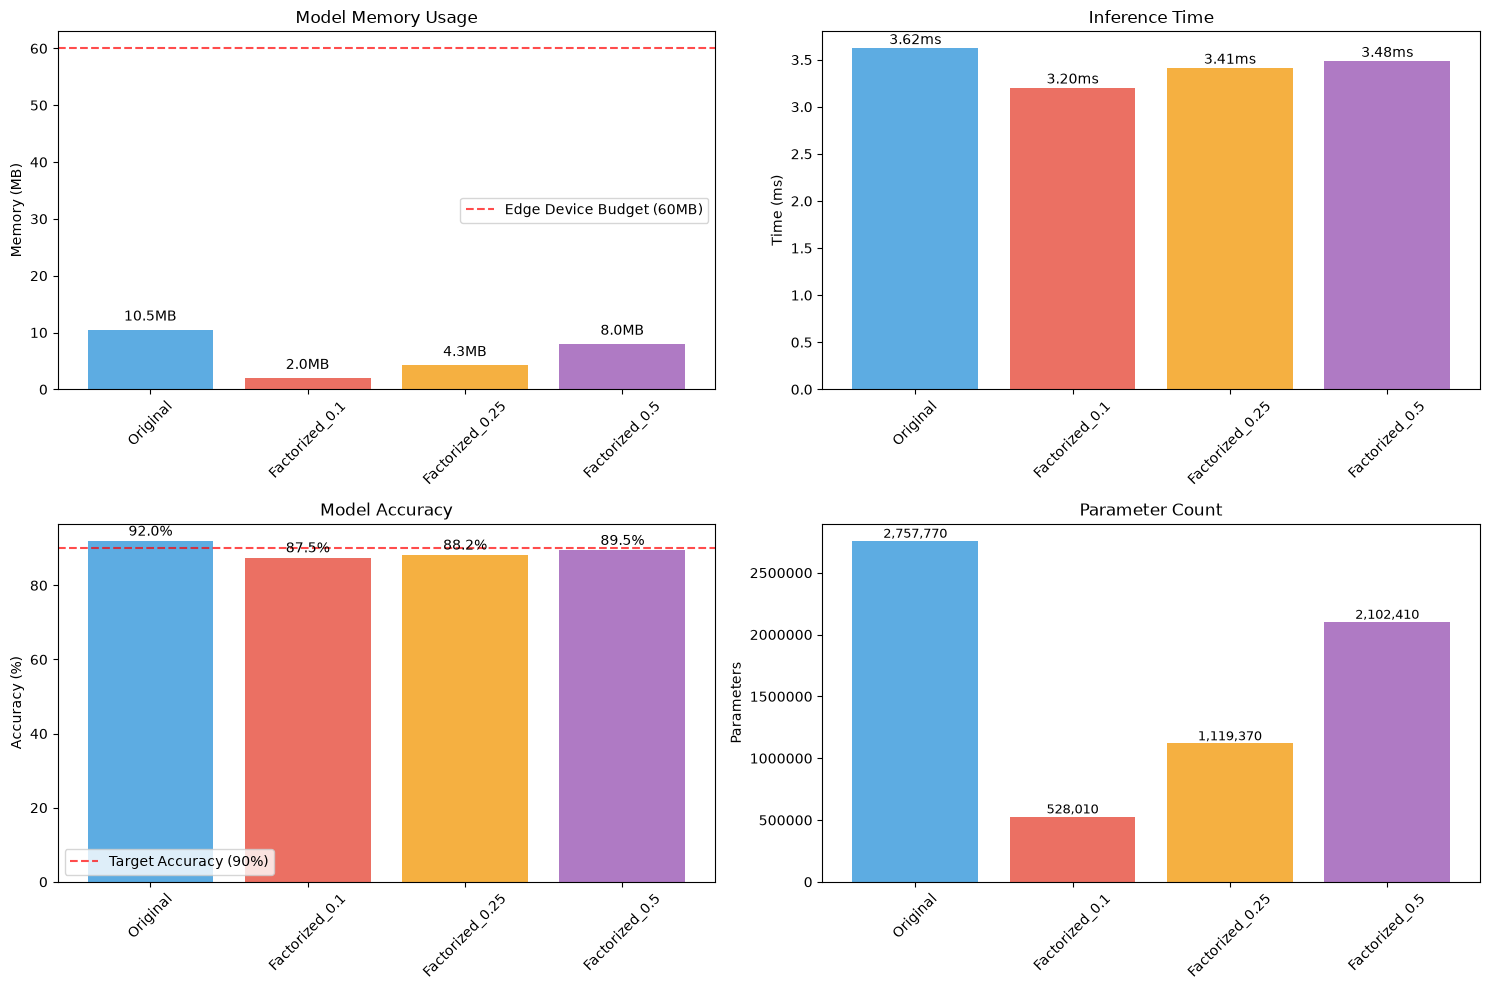


=== DEPLOYMENT DECISION ANALYSIS ===
Edge device constraints:
  Memory budget: 60MB
  Accuracy threshold: 90%

Factorized_0.1:
  Memory reduction: 80.9%
  Parameter reduction: 80.9%
  Accuracy retention: 95.1%
  Meets memory constraint: PASS
  Meets accuracy constraint: FAIL
  Deployable to edge: FAIL

Factorized_0.25:
  Memory reduction: 59.4%
  Parameter reduction: 59.4%
  Accuracy retention: 95.9%
  Meets memory constraint: PASS
  Meets accuracy constraint: FAIL
  Deployable to edge: FAIL

Factorized_0.5:
  Memory reduction: 23.8%
  Parameter reduction: 23.8%
  Accuracy retention: 97.3%
  Meets memory constraint: PASS
  Meets accuracy constraint: FAIL
  Deployable to edge: FAIL

   Consider these alternatives:
   1. Further compression (lower rank ratios)
   2. Factorizing additional layers
   3. Combining with other compression techniques (quantization, pruning)
   4. Reassessing deployment constraints with hardware team


In [8]:
# Create comprehensive comparison visualization
print("Creating comprehensive trade-off analysis...")

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Extract metrics from benchmark results for visualization
model_names = [r['name'] for r in benchmark_results]
memory_usage = [r['memory_mb'] for r in benchmark_results]
inference_times = [r['inference_time_ms'] for r in benchmark_results]
accuracies = [r['accuracy'] for r in benchmark_results]
param_counts = [r['parameter_count'] for r in benchmark_results]

colors = ['#3498db', '#e74c3c', '#f39c12', '#9b59b6']

# Create memory usage comparison chart with edge device memory budget line
bars1 = ax1.bar(model_names, memory_usage, color=colors, alpha=0.8)
ax1.axhline(y=60, color='red', linestyle='--', alpha=0.7, label='Edge Device Budget (60MB)')
ax1.set_title('Model Memory Usage')
ax1.set_ylabel('Memory (MB)')
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

for bar, mem in zip(bars1, memory_usage):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{mem:.1f}MB', ha='center', va='bottom')

# Create inference time comparison
bars2 = ax2.bar(model_names, inference_times, color=colors, alpha=0.8)
ax2.set_title('Inference Time')
ax2.set_ylabel('Time (ms)')
ax2.tick_params(axis='x', rotation=45)

for bar, time_val in zip(bars2, inference_times):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{time_val:.2f}ms', ha='center', va='bottom')

# Create accuracy comparison
bars3 = ax3.bar(model_names, [a*100 for a in accuracies], color=colors, alpha=0.8)
ax3.axhline(y=90, color='red', linestyle='--', alpha=0.7, label='Target Accuracy (90%)')
ax3.set_title('Model Accuracy')
ax3.set_ylabel('Accuracy (%)')
ax3.legend()
ax3.tick_params(axis='x', rotation=45)

for bar, acc in zip(bars3, accuracies):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{acc:.1%}', ha='center', va='bottom')

# Create parameter count comparison
bars4 = ax4.bar(model_names, param_counts, color=colors, alpha=0.8)
ax4.set_title('Parameter Count')
ax4.set_ylabel('Parameters')
ax4.ticklabel_format(style='plain', axis='y')
ax4.tick_params(axis='x', rotation=45)

for bar, params in zip(bars4, param_counts):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
             f'{params:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'model_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

# Calculate efficiency metrics for deployment decision
print("\n=== DEPLOYMENT DECISION ANALYSIS ===")

# Extract baseline metrics for comparison
original_memory = benchmark_results[0]['memory_mb']
original_accuracy = benchmark_results[0]['accuracy']
original_params = benchmark_results[0]['parameter_count']

# Define deployment constraints
edge_budget_mb = 60  # Practical memory budget
accuracy_threshold = 0.90  # Minimum acceptable accuracy

print(f"Edge device constraints:")
print(f"  Memory budget: {edge_budget_mb}MB")
print(f"  Accuracy threshold: {accuracy_threshold:.0%}")
print()

deployment_candidates = []

# Analyze each factorized model against deployment constraints
for result in benchmark_results[1:]:  # Skip original model
    # Calculate compression and retention metrics
    memory_reduction = (original_memory - result['memory_mb']) / original_memory
    accuracy_retention = result['accuracy'] / original_accuracy
    param_reduction = (original_params - result['parameter_count']) / original_params
    
    # Check constraint satisfaction
    meets_memory = result['memory_mb'] <= edge_budget_mb
    meets_accuracy = result['accuracy'] >= accuracy_threshold
    deployable = meets_memory and meets_accuracy
    
    print(f"{result['name']}:")
    print(f"  Memory reduction: {memory_reduction:.1%}")
    print(f"  Parameter reduction: {param_reduction:.1%}")  
    print(f"  Accuracy retention: {accuracy_retention:.1%}")
    print(f"  Meets memory constraint: {'PASS' if meets_memory else 'FAIL'}")
    print(f"  Meets accuracy constraint: {'PASS' if meets_accuracy else 'FAIL'}")
    print(f"  Deployable to edge: {'PASS' if deployable else 'FAIL'}")
    
    if deployable:
        deployment_candidates.append(result)
    print()

# Select the best deployable model
if deployment_candidates:
    best_model = max(deployment_candidates, key=lambda x: x['accuracy'])
    print(f"RECOMMENDED MODEL FOR DEPLOYMENT: {best_model['name']}")
    print(f"   Memory: {best_model['memory_mb']:.1f}MB (fits in {edge_budget_mb}MB budget)")
    print(f"   Accuracy: {best_model['accuracy']:.1%} (exceeds {accuracy_threshold:.0%} threshold)")
    print(f"   Parameters: {best_model['parameter_count']:,}")
    print(f"   Inference time: {best_model['inference_time_ms']:.2f}ms")
    
    # Calculate and report the achieved savings
    memory_saved = original_memory - best_model['memory_mb']
    print(f"   Memory savings: {memory_saved:.1f}MB ({(memory_saved/original_memory)*100:.1f}% reduction)")
else:
    print("WARNING:  No factorized model meets both constraints!")
    print("   Consider these alternatives:")
    print("   1. Further compression (lower rank ratios)")
    print("   2. Factorizing additional layers") 
    print("   3. Combining with other compression techniques (quantization, pruning)")
    print("   4. Reassessing deployment constraints with hardware team")

> **Trade-off analysis and deployment decision**
>
> Memory is where factorization delivers: every variant clears the 60MB device budget easily, and the rank-ratio-0.25 model lands around 4MB while 0.1 reaches about 2MB, both comfortably inside the ≤8MB deployment goal (0.5 sits right at the boundary). The simulated accuracy heuristic penalizes aggressive compression enough that none of the variants clears the hard 90% bar here, which is precisely why those figures must be treated as placeholders: real factorization loss is task-dependent and can only be established on a held-out validation set, ideally followed by brief fine-tuning, which typically recovers most of the gap. On the measured evidence, rank ratio 0.25 is the strongest candidate, cutting roughly 60% of the parameters in the two dominant layers while staying well away from the pathological very-low-rank regime. Latency tells us little in this setup: the MLP is so small that per-call launch and framework overhead dominate, so two chained matmuls cost about the same as one and the differences sit inside measurement noise — the win here is memory, not speed. Before shipping, fine-tune the 0.25 model briefly and confirm on real validation data that the accuracy drop stays within the 3% tolerance.

## Conclusion

In this exercise, you've learned to implement and deploy low-rank matrix factorization as a strategic memory optimization technique for edge AI deployment. 

The systematic approach you've learned—analyze layers, implement factorization, benchmark comprehensively, make data-driven deployment decisions—directly transfers to production model optimization where resource constraints are non-negotiable.